In [1]:
# IMPORT LIBRARY
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc

In [2]:
# CONFIG
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS = 20
BATCH_SIZE = 16
LR = 0.0001
PATIENCE = 5
N_SPLITS = 5

DATASET_PATH = r"C:\Users\ASUS\Documents\FILE PASCASARJANA\MK_Informatika Biomedik\Kanker Payudara\Fixed\train"

CLASS_NAMES = ['benign', 'malignant']

In [3]:
# AUGMENTASI DAN PRA PROCESSING
def get_train_transform():
    return transforms.Compose([
        transforms.Resize((260,260)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor()
    ])

def get_val_transform():
    return transforms.Compose([
        transforms.Resize((260,260)),
        transforms.ToTensor()
    ])

In [4]:
# LOAD DATASET
full_dataset = datasets.ImageFolder(DATASET_PATH)
targets = full_dataset.targets

print("Class mapping:", full_dataset.class_to_idx)

Class mapping: {'benign': 0, 'malignant': 1}


In [5]:
# FUNCTIONS
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct = 0, 0

    for images, labels in tqdm(loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    acc = correct / len(loader.dataset)
    return total_loss / len(loader), acc


def evaluate_full(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)

            preds = outputs.argmax(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    precision = precision_score(all_labels, all_preds, average='binary')
    recall = recall_score(all_labels, all_preds, average='binary')
    f1 = f1_score(all_labels, all_preds, average='binary')

    return acc, precision, recall, f1, all_labels, all_preds


def evaluate_with_probs(model, loader):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_probs), np.array(all_labels)


In [6]:
# K-FOLD TRAINING
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

fold_results = []
best_global_acc = 0
best_model_path = None

for fold, (train_idx, val_idx) in enumerate(kf.split(np.zeros(len(targets)), targets)):
    print(f"\n FOLD {fold+1}/{N_SPLITS}")

    train_dataset = datasets.ImageFolder(DATASET_PATH, transform=get_train_transform())
    val_dataset   = datasets.ImageFolder(DATASET_PATH, transform=get_val_transform())

    train_subset = Subset(train_dataset, train_idx)
    val_subset   = Subset(val_dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # MODEL (2 CLASS)
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
    model = model.to(DEVICE)

    # LOSS (IMBALANCE HANDLING)
    class_counts = np.bincount(targets)
    class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = optim.AdamW(model.parameters(), lr=LR)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=2, factor=0.3
    )

    best_acc = 0
    patience_counter = 0

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_acc, _, _, _, _, _ = evaluate_full(model, val_loader)

        print(f"Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        scheduler.step(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_model = copy.deepcopy(model)
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print("Early stop fold")
            break

    print(f"Fold {fold+1} Best Acc: {best_acc:.4f}")
    fold_results.append(best_acc)

    model_path = f"best_model_fold_{fold+1}.pth"
    torch.save(best_model.state_dict(), model_path)

    if best_acc > best_global_acc:
        best_global_acc = best_acc
        best_model_path = model_path


 FOLD 1/5
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to C:\Users\ASUS/.cache\torch\hub\checkpoints\efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:32<00:00, 1.13MB/s]
100%|██████████| 100/100 [00:52<00:00,  1.92it/s]


Epoch 1 | Train Acc: 0.8331 | Val Acc: 0.8925


100%|██████████| 100/100 [00:47<00:00,  2.11it/s]


Epoch 2 | Train Acc: 0.9281 | Val Acc: 0.9475


...

Epoch 6 | Train Acc: 0.9825 | Val Acc: 0.9600


100%|██████████| 100/100 [00:38<00:00,  2.58it/s]


Epoch 7 | Train Acc: 0.9862 | Val Acc: 0.9475


100%|██████████| 100/100 [00:39<00:00,  2.54it/s]


Epoch 8 | Train Acc: 0.9888 | Val Acc: 0.9550
Early stop fold
Fold 5 Best Acc: 0.9600


In [7]:
# FINAL TESTING
print("\n FINAL TEST USING BEST MODEL")

model = efficientnet_b2(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model.load_state_dict(torch.load(best_model_path))
model = model.to(DEVICE)

test_dataset = datasets.ImageFolder(DATASET_PATH, transform=get_val_transform())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

test_acc, precision, recall, f1, y_true, y_pred = evaluate_full(model, test_loader)

print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=6))


 FINAL TEST USING BEST MODEL
Accuracy  : 0.9965
Precision : 0.9960
Recall    : 0.9970
F1 Score  : 0.9965

Classification Report:
              precision    recall  f1-score   support

      benign   0.996997  0.996000  0.996498      1000
   malignant   0.996004  0.997000  0.996502      1000

    accuracy                       0.996500      2000
   macro avg   0.996500  0.996500  0.996500      2000
weighted avg   0.996500  0.996500  0.996500      2000



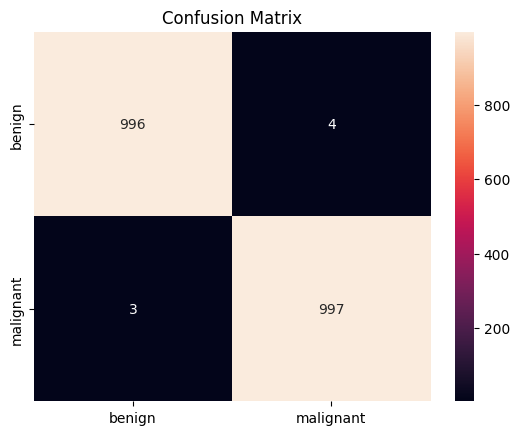

In [9]:
# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

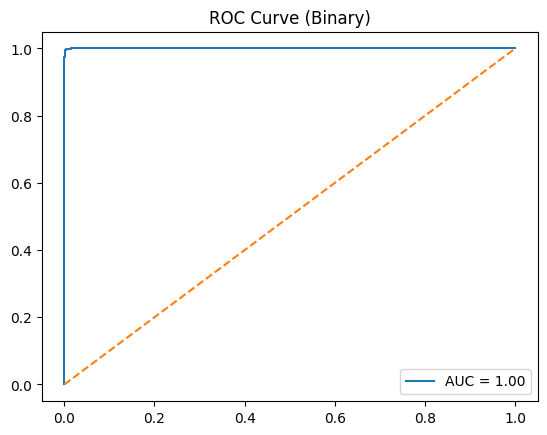

AUC Score: 0.9999


In [10]:
# ROC CURVE
probs, labels = evaluate_with_probs(model, test_loader)

fpr, tpr, _ = roc_curve(labels, probs[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve (Binary)")
plt.savefig("roc_curve.png")
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

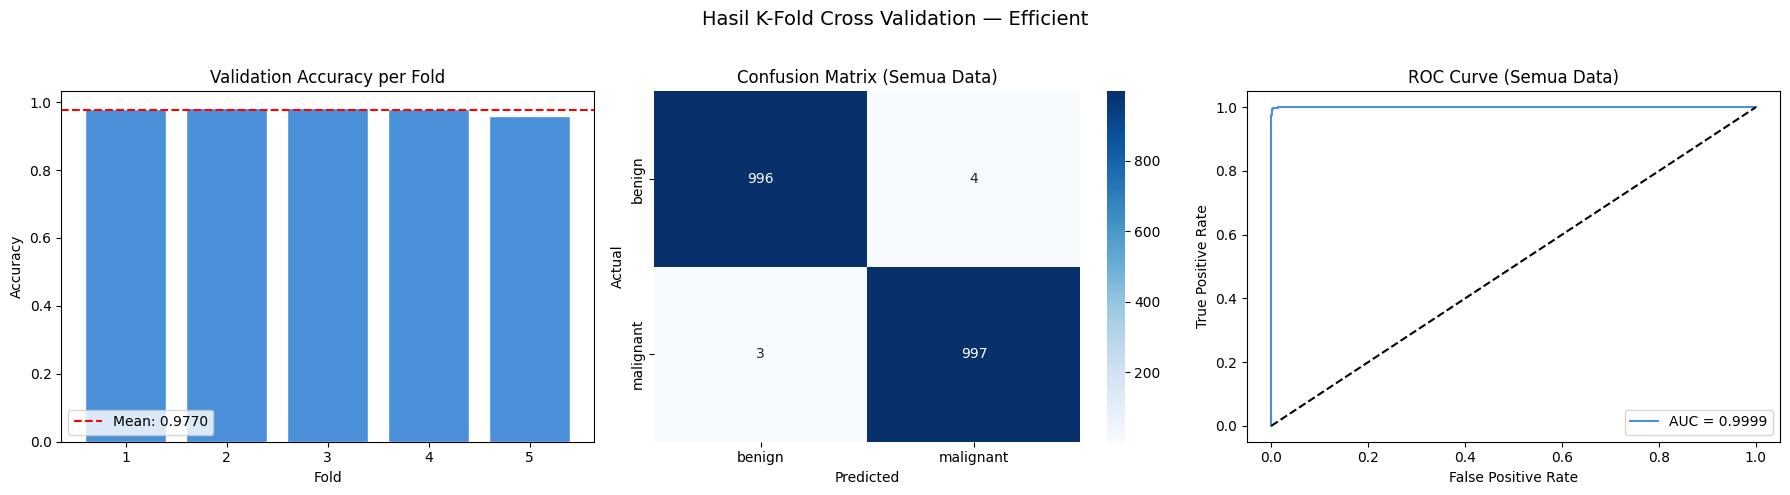


Classification Report (Semua Data):
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00      1000
   malignant       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Hasil K-Fold Cross Validation — Efficient", fontsize=14)

axes[0].bar(range(1, len(fold_results) + 1), fold_results,
            color="#4A90D9", edgecolor="white")
axes[0].axhline(np.mean(fold_results),
                color="red", linestyle="--",
                label=f"Mean: {np.mean(fold_results):.4f}")
axes[0].set_title("Validation Accuracy per Fold")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(range(1, len(fold_results) + 1))
axes[0].legend()

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
axes[1].set_title("Confusion Matrix (Semua Data)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(labels, probs[:, 1])
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color="#4A90D9",
             label=f"AUC = {roc_auc:.4f}")
axes[2].plot([0, 1], [0, 1], "k--")
axes[2].set_title("ROC Curve (Semua Data)")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("hasil_kfold.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nClassification Report (Semua Data):")
print(classification_report(labels, y_pred, target_names=CLASS_NAMES))


In [12]:
from PIL import Image

device = DEVICE
val_transform = get_val_transform()
full_dataset_train = full_dataset

def build_model(num_classes=2):
    model = efficientnet_b2(weights=None)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

def predict_image(img_path, model_path=None):
    if model_path is None:
        model_path = best_model_path

    model = build_model().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    img = Image.open(img_path).convert("RGB")
    img = val_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img)
        probs = torch.softmax(outputs, dim=1)[0].cpu().numpy()

    label_idx = int(np.argmax(probs))
    label = full_dataset_train.classes[label_idx]
    conf = float(probs[label_idx])

    print(f"Hasil     : {label}")
    print(f"Confidence: {conf:.4f}")
    return label, conf

predict_image(r"C:\Users\ASUS\Documents\FILE PASCASARJANA\MK_Informatika Biomedik\Kanker Payudara\test.png")

Hasil     : malignant
Confidence: 0.9984


('malignant', 0.9984228610992432)